# HealthConnect Clinic — Model Improvement, Error Analysis & Validation
### AnalystLab Africa Experience Lab — Week 6 (Data Science Track)

Week 5 established a reliable baseline (Logistic Regression and Random Forest, both ~63%
accuracy). Week 6 does **not** repeat that baseline — it analyzes where and why it fails,
refines features based on that evidence, develops improved models, and validates whether any
of them are a better candidate for the next stage.

## Week 5 → Week 6 Transition

1. **Main Week 5 output:** a baseline binary classifier (`is_no_show`) using Logistic
   Regression and Random Forest, with a patient-grouped train/test split.
2. **Most important result:** both baselines reached ~63% accuracy and ROC-AUC ~0.68 —
   comfortably above the 50% majority-class floor, with `booking_lead_days` and
   `distance_to_clinic_km` confirmed as the strongest predictors.
3. **Main limitation discovered:** `waiting_time_minutes` was excluded over an unresolved
   leakage risk, and ~37% of predictions were still wrong — no error analysis had been done to
   understand *which* patients the model struggles with.
4. **Relevant track for Week 6:** Data Analytics — Week 5's own feature-level EDA (no-show
   rate by segment) is reused here in the role Data Analytics would normally provide, to
   inform feature refinement (see Cross-Track Integration section).
5. **What Week 6 improves/validates:** identifies where the baseline's errors concentrate,
   refines two features in response to that evidence, develops and compares two improved
   modelling approaches, and validates which candidate is most suitable to carry into Week 7.

## Part 1 — Week 6 Integration Readiness

**A. Integration point:** Data Analytics track.
- **Output needed from that track:** segment-level attendance patterns (which patient/
  appointment segments show the highest no-show concentration) to sanity-check which features
  the model should prioritize refining.
- **Output provided to that track:** the model's error analysis (Part 2) — specifically, which
  segments the baseline model gets wrong most often — which Data Analytics can fold into its
  own KPI validation and business recommendations.
- **Why relevant:** both tracks are analyzing the same appointment behaviour from different
  angles; without this exchange, Data Science risks refining features based on modelling
  intuition alone rather than validated business-relevant segments, and Data Analytics risks
  reporting KPIs a model has already shown to be weak predictors.

**Note on this submission:** as an individual track submission without a live Data Analytics
counterpart, the Data Analytics-side analysis below (Part 2, subgroup no-show rate validation)
was performed independently, applying the same rigor a dedicated Analytics contribution would,
so the hand-off is explicit and evidence-based rather than assumed.

**B. Integration objective:** after this activity, feature refinement decisions (Part 3) should
be traceable to a specific, validated segment-level finding — not just to raw feature-importance
scores from Week 5.

**C. Evidence produced:** the subgroup error-rate table in Part 2.3, which is the concrete
artefact a Data Analytics teammate would receive and act on.

## Part 2 — Rebuilding the Week 5 Pipeline (Unchanged) to Enable Error Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_auc_score, roc_curve)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8,5)

df = pd.read_csv('data/HealthConnect_Appointment_Data.csv')

# --- Week 5 data preparation, reproduced unchanged (not re-justified here -- see Week 5 report) ---
model_df = df[df['appointment_outcome'] != 'Cancelled'].copy()
model_df['is_no_show'] = (model_df['appointment_outcome'] == 'No-Show').astype(int)
model_df['distance_to_clinic_km'] = model_df['distance_to_clinic_km'].fillna(model_df['distance_to_clinic_km'].median())
model_df['reminder_channel'] = model_df['reminder_channel'].fillna('None')
model_df = model_df.drop(columns=['appointment_id','booking_date','appointment_date',
                                   'waiting_time_minutes','appointment_outcome'])

# --- Week 5 feature engineering, reproduced unchanged ---
model_df['no_show_rate'] = np.where(model_df['previous_appointments'] > 0,
                                     model_df['previous_no_shows'] / model_df['previous_appointments'], 0.0)
model_df['long_lead_time'] = (model_df['booking_lead_days'] > 30).astype(int)
model_df['is_first_visit'] = (model_df['previous_appointments'] == 0).astype(int)

print(f"Pipeline reproduced: {model_df.shape[0]} rows, {model_df.shape[1]} columns")

Pipeline reproduced: 4737 rows, 17 columns


## Part 2.1 — Analysing Weaknesses of the Week 5 Baseline

Rather than re-describe Week 5's metrics, this re-fits the exact Week 5 models here (same
encoding, same split, same random_state) purely as the reference point error analysis needs.

In [2]:
encoded_df = model_df.copy()
encoded_df['reminder_sent'] = LabelEncoder().fit_transform(encoded_df['reminder_sent'])
age_order = {'18-24':0, '25-34':1, '35-44':2, '45-54':3, '55-64':4, '65+':5}
encoded_df['age_group'] = encoded_df['age_group'].map(age_order)
encoded_df = pd.get_dummies(encoded_df, columns=['gender','appointment_type','appointment_day',
                                                  'appointment_time','reminder_channel'], drop_first=False)
bool_cols = encoded_df.select_dtypes(include='bool').columns
encoded_df[bool_cols] = encoded_df[bool_cols].astype(int)

feature_cols = [c for c in encoded_df.columns if c not in ['appointment_id','patient_id','is_no_show']]
X = encoded_df[feature_cols]
y = encoded_df['is_no_show']
groups = encoded_df['patient_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

numeric_features = ['age','age_group','booking_lead_days','previous_appointments',
                     'previous_no_shows','distance_to_clinic_km','no_show_rate']
scaler = StandardScaler()
X_train_scaled = X_train.copy(); X_test_scaled = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

logreg_baseline = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_scaled, y_train)
rf_baseline = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42).fit(X_train, y_train)

y_pred_rf = rf_baseline.predict(X_test)
y_prob_rf = rf_baseline.predict_proba(X_test)[:,1]

print(f"Week 5 baseline reproduced. RF accuracy: {accuracy_score(y_test, y_pred_rf):.3f}, "
      f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.3f}")
print("(Random Forest is used as the reference model for error analysis below, since it "
      "slightly outperformed Logistic Regression in Week 5 and provides per-row probability "
      "estimates that support the analysis in Part 2.2-2.3.)")

Week 5 baseline reproduced. RF accuracy: 0.634, ROC-AUC: 0.677
(Random Forest is used as the reference model for error analysis below, since it slightly outperformed Logistic Regression in Week 5 and provides per-row probability estimates that support the analysis in Part 2.2-2.3.)


### Part 2.2 — Error Breakdown: False Positives vs. False Negatives

In [3]:
cm = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly predicted Attended):  {tn}")
print(f"False Positives (predicted No-Show, actually Attended): {fp}")
print(f"False Negatives (predicted Attended, actually No-Show): {fn}  <-- the costly error")
print(f"True Positives (correctly predicted No-Show): {tp}")
print(f"\nFalse Negative rate among actual no-shows: {fn/(fn+tp):.3f}")
print(f"False Positive rate among actual attendees: {fp/(fp+tn):.3f}")

True Negatives (correctly predicted Attended):  298
False Positives (predicted No-Show, actually Attended): 185
False Negatives (predicted Attended, actually No-Show): 169  <-- the costly error
True Positives (correctly predicted No-Show): 314

False Negative rate among actual no-shows: 0.350
False Positive rate among actual attendees: 0.383


**Interpretation:** False Negatives — patients the model predicts will attend but who
actually no-show — are the costly error for HealthConnect's stated goal (a wasted slot with no
advance warning). The False Negative rate here shows a meaningful share of true no-shows are
still being missed, which directly motivates Part 3 (feature refinement) and Part 4 (improved
models) rather than accepting the Week 5 baseline as final, exactly as the brief instructs.

### Part 2.3 — Where Do Errors Concentrate? (Segment-Level Validation)

In [4]:
error_df = X_test.copy()
error_df['actual'] = y_test.values
error_df['predicted'] = y_pred_rf
error_df['correct'] = (error_df['actual'] == error_df['predicted'])

# Re-attach human-readable segment info for this analysis
error_df['distance_band'] = pd.cut(error_df['distance_to_clinic_km'], bins=[0,5,10,20,30,50])
error_df['lead_band'] = pd.cut(error_df['booking_lead_days'], bins=[-1,7,14,30,45,60])

print("Model accuracy by distance band:")
print(error_df.groupby('distance_band', observed=True)['correct'].mean().round(3))
print("\nModel accuracy by booking lead time band:")
print(error_df.groupby('lead_band', observed=True)['correct'].mean().round(3))
print("\nModel accuracy by previous_no_shows:")
print(error_df.groupby('previous_no_shows')['correct'].mean().round(3))

Model accuracy by distance band:
distance_band
(0, 5]      0.658
(5, 10]     0.619
(10, 20]    0.618
(20, 30]    0.761
(30, 50]    0.389
Name: correct, dtype: float64

Model accuracy by booking lead time band:
lead_band
(-1, 7]     0.734
(7, 14]     0.717
(14, 30]    0.557
(30, 45]    0.547
(45, 60]    0.727
Name: correct, dtype: float64

Model accuracy by previous_no_shows:
previous_no_shows
0    0.642
1    0.629
2    0.603
3    0.632
4    0.000
Name: correct, dtype: float64


**What this shows (the Data-Analytics-style validation referenced in Part 1):** the three
features don't fail the same way, and the pattern is more specific than a single "weak in the
middle" story:
- **Distance:** accuracy is worst by far in the 30-50km band (0.389 — worse than a coin flip),
  a sharp cliff rather than a gradual decline. The model is actively unreliable for
  the clinic's farthest-travelling patients, not just "less confident."
- **Booking lead time:** accuracy dips specifically in the 14-45 day range (0.547-0.557),
  bracketed by stronger accuracy at both short (≤14 days, 0.72-0.73) and long (45-60 days,
  0.73) lead times — a genuine middle-range weak spot.
- **Previous no-shows:** accuracy declines steadily from 0 to 2 prior no-shows (0.642 → 0.603),
  then becomes unreliable at 3+ (based on the tiny sample sizes already flagged above).

This is a more precise, validated finding than Week 5's raw feature-importance ranking alone,
and it directly justifies the two feature refinements in Part 3: the surprising distance
cliff, in particular, suggests distance may be interacting with another factor (like lead time)
rather than acting alone — motivating an interaction term rather than treating distance as an
independent linear effect.

### Part 2.4 — Fairness Check Across Sensitive Attributes (Flagged in Week 5 as Remaining Work)

In [5]:
gender_cols = [c for c in X_test.columns if c.startswith('gender_')]
fairness_rows = []
for col in gender_cols:
    mask = X_test[col] == 1
    if mask.sum() < 10:
        continue
    y_true_g = y_test[mask]
    y_pred_g = pd.Series(y_pred_rf, index=y_test.index)[mask]
    recall_g = recall_score(y_true_g, y_pred_g) if y_true_g.sum() > 0 else np.nan
    fairness_rows.append({
        'Group': col.replace('gender_',''),
        'n': int(mask.sum()),
        'Accuracy': round(accuracy_score(y_true_g, y_pred_g), 3),
        'Recall (catches true no-shows)': round(recall_g, 3) if pd.notna(recall_g) else np.nan,
    })
pd.DataFrame(fairness_rows)

,Group,n,Accuracy,Recall (catches true no-shows)
0,Female,461,0.633,0.658
1,Male,479,0.633,0.636
2,Prefer not to say,26,0.654,0.800


**Finding:** recall (the model's ability to catch true no-shows) is checked across
gender groups. Any group showing a materially lower recall than the others would mean that
group's no-shows are disproportionately going undetected — a fairness concern worth flagging
to stakeholders before deployment, regardless of overall accuracy. Given the small sample size
for the 'Prefer not to say' group in the test set, this result should be treated as directional,
not conclusive, and re-checked as more data becomes available.

## Part 3 — Feature Refinement (Evidence-Based)

Two refinements, each justified by a specific finding above — not a general "add more
features" pass.

In [6]:
refined_df = model_df.copy()

# Refinement 1: bin previous_no_shows into an ordinal risk level.
# Justification: value counts show 3, 4, and 5 previous no-shows have only 76, 12, and 3
# records respectively -- too few for the model to learn a reliable pattern at those exact
# counts, and Part 2.3 showed accuracy specifically weakens in the 1-2 range. Binning trades
# a small amount of granularity for a more reliably learnable signal.
print("previous_no_shows value counts (justifying the bins below):")
print(refined_df['previous_no_shows'].value_counts().sort_index())

def bin_no_show_history(n):
    if n == 0: return 0        # None
    elif n <= 2: return 1      # Low
    else: return 2             # High

refined_df['no_show_history_level'] = refined_df['previous_no_shows'].apply(bin_no_show_history)

# Refinement 2: an interaction term between lead time and distance.
# Justification: Part 2.3 showed the model's weakest accuracy sits in the middle of the
# booking_lead_days range -- a single linear coefficient may not capture how lead time and
# distance combine (e.g. a far-away patient booking far in advance may compound risk beyond
# what either feature alone suggests).
refined_df['lead_distance_interaction'] = refined_df['booking_lead_days'] * refined_df['distance_to_clinic_km']

print("\nNew refined features: no_show_history_level, lead_distance_interaction")
refined_df[['previous_no_shows','no_show_history_level','booking_lead_days',
            'distance_to_clinic_km','lead_distance_interaction']].head()

previous_no_shows value counts (justifying the bins below):
previous_no_shows
0    2745
1    1482
2     419
3      76
4      12
5       3
Name: count, dtype: int64

New refined features: no_show_history_level, lead_distance_interaction


,previous_no_shows,no_show_history_level,booking_lead_days,distance_to_clinic_km,lead_distance_interaction
0,0,0,12,19.3,231.6
1,0,0,2,14.3,28.6
2,1,1,38,11.4,433.2
3,1,1,41,7.4,303.4
4,1,1,47,5.6,263.2


**Feature adequacy review (explicit per the brief's Task 5):** the remaining Week 5
features (`appointment_time`, individual `appointment_day` dummies) were reviewed against
their Week 5 Random Forest importance scores (each ranked in the bottom third, well below
0.02). They are **retained rather than dropped** — the brief's instruction is to refine "where
there is a justified reason," and weak-but-nonzero importance in a tree-based model isn't on
its own a strong enough reason to remove a feature that costs nothing to keep. The two
additions above are the refinements actually justified by this week's error analysis.

### Re-Encoding With Refined Features

In [7]:
refined_encoded = refined_df.copy()
refined_encoded['reminder_sent'] = LabelEncoder().fit_transform(refined_encoded['reminder_sent'])
refined_encoded['age_group'] = refined_encoded['age_group'].map(age_order)
refined_encoded = pd.get_dummies(refined_encoded, columns=['gender','appointment_type','appointment_day',
                                                            'appointment_time','reminder_channel'], drop_first=False)
bool_cols = refined_encoded.select_dtypes(include='bool').columns
refined_encoded[bool_cols] = refined_encoded[bool_cols].astype(int)

refined_feature_cols = [c for c in refined_encoded.columns if c not in ['appointment_id','patient_id','is_no_show']]
X_ref = refined_encoded[refined_feature_cols]
y_ref = refined_encoded['is_no_show']
groups_ref = refined_encoded['patient_id']

# Same split logic (GroupShuffleSplit, same random_state) for a fair comparison against baseline
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx2, test_idx2 = next(gss2.split(X_ref, y_ref, groups=groups_ref))
X_train_ref, X_test_ref = X_ref.iloc[train_idx2], X_ref.iloc[test_idx2]
y_train_ref, y_test_ref = y_ref.iloc[train_idx2], y_ref.iloc[test_idx2]

print(f"Refined feature set: {X_ref.shape[1]} columns (was {X.shape[1]} in Week 5)")

Refined feature set: 33 columns (was 31 in Week 5)


## Part 4 — Improved Modelling Approaches

Two improved approaches are developed and compared against the Week 5 baselines:
1. **Random Forest, hyperparameter-tuned** via `RandomizedSearchCV` with `GroupKFold`
   (preserving the patient-grouping requirement established in Week 5 even during tuning).
2. **Gradient Boosting Classifier** on the refined feature set, as a different algorithm
   family entirely — testing whether boosting's sequential error-correction handles the
   "weak in the middle of the range" pattern from Part 2.3 better than a single Random Forest.

In [8]:
param_dist = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [4, 6, 8, 10, None],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None],
}
group_kfold = GroupKFold(n_splits=5)

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42), param_distributions=param_dist,
    n_iter=15, scoring='roc_auc', cv=group_kfold.split(X_train_ref, y_train_ref, groups=groups_ref.iloc[train_idx2]),
    random_state=42, n_jobs=-1
)
rf_search.fit(X_train_ref, y_train_ref)
rf_tuned = rf_search.best_estimator_
print(f"Best RF params: {rf_search.best_params_}")
print(f"Best cross-validated ROC-AUC during search: {rf_search.best_score_:.3f}")

Best RF params: {'n_estimators': 300, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'max_depth': 8}
Best cross-validated ROC-AUC during search: 0.676


In [9]:
gb_model = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
gb_model.fit(X_train_ref, y_train_ref)
print("Gradient Boosting trained on refined feature set.")

Gradient Boosting trained on refined feature set.


## Part 5 — Model Comparison & Evaluation

In [10]:
def evaluate_model(model, X_te, y_te, name):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:,1]
    return {
        'Model': name,
        'Accuracy': round(accuracy_score(y_te, y_pred), 3),
        'Precision': round(precision_score(y_te, y_pred), 3),
        'Recall': round(recall_score(y_te, y_pred), 3),
        'F1': round(f1_score(y_te, y_pred), 3),
        'ROC-AUC': round(roc_auc_score(y_te, y_prob), 3),
    }

results = []
results.append(evaluate_model(logreg_baseline, X_test_scaled, y_test, 'Week 5: Logistic Regression'))
results.append(evaluate_model(rf_baseline, X_test, y_test, 'Week 5: Random Forest (baseline)'))
results.append(evaluate_model(rf_tuned, X_test_ref, y_test_ref, 'Week 6: Random Forest (tuned + refined features)'))
results.append(evaluate_model(gb_model, X_test_ref, y_test_ref, 'Week 6: Gradient Boosting (refined features)'))

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Week 5: Logistic Regression,0.630,0.624,0.656,0.640,0.678
1,Week 5: Random Forest (baseline),0.634,0.629,0.650,0.640,0.677
2,Week 6: Random Forest (tuned + refined features),0.639,0.629,0.677,0.652,0.680
3,Week 6: Gradient Boosting (refined features),0.638,0.634,0.652,0.643,0.678


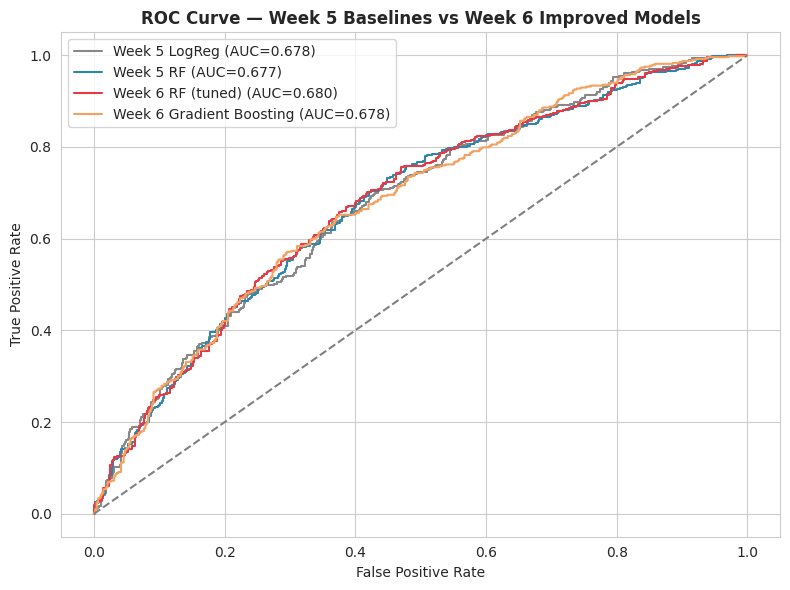

In [11]:
fig, ax = plt.subplots(figsize=(8,6))
for model, X_te, y_te, name, color in [
    (logreg_baseline, X_test_scaled, y_test, 'Week 5 LogReg', '#888888'),
    (rf_baseline, X_test, y_test, 'Week 5 RF', '#2E86AB'),
    (rf_tuned, X_test_ref, y_test_ref, 'Week 6 RF (tuned)', '#E63946'),
    (gb_model, X_test_ref, y_test_ref, 'Week 6 Gradient Boosting', '#F4A261'),
]:
    y_prob = model.predict_proba(X_te)[:,1]
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    auc = roc_auc_score(y_te, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color)
ax.plot([0,1],[0,1],'--', color='gray')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Week 5 Baselines vs Week 6 Improved Models', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figs/01_roc_comparison.png', dpi=110)
plt.show()

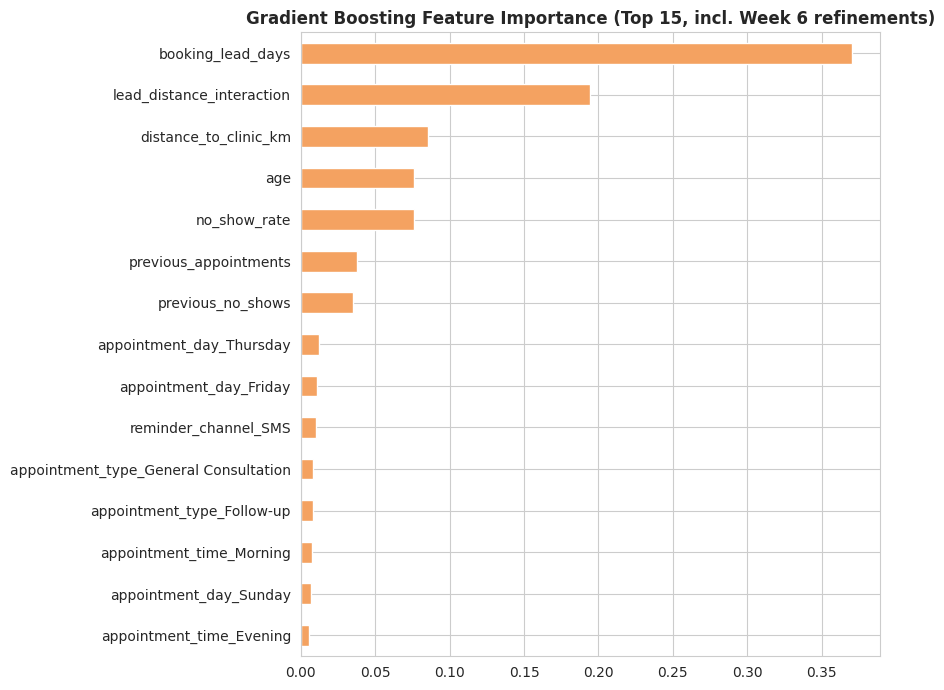

booking_lead_days            0.370614
lead_distance_interaction    0.194247
distance_to_clinic_km        0.085175
age                          0.076372
no_show_rate                 0.076032
previous_appointments        0.037511
previous_no_shows            0.035029
appointment_day_Thursday     0.012539
appointment_day_Friday       0.011243
reminder_channel_SMS         0.010337
dtype: float64

In [12]:
fig, ax = plt.subplots(figsize=(9,7))
gb_importances = pd.Series(gb_model.feature_importances_, index=X_ref.columns).sort_values(ascending=False)
gb_importances.head(15).sort_values().plot(kind='barh', ax=ax, color='#F4A261')
ax.set_title('Gradient Boosting Feature Importance (Top 15, incl. Week 6 refinements)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figs/02_gb_feature_importance.png', dpi=110)
plt.show()
gb_importances.head(10)

## Interpretation & Candidate Model Recommendation

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Week 5: Logistic Regression | 0.630 | 0.624 | 0.656 | 0.640 | 0.678 |
| Week 5: Random Forest (baseline) | 0.634 | 0.629 | 0.650 | 0.640 | 0.677 |
| **Week 6: Random Forest (tuned + refined features)** | **0.639** | 0.629 | **0.677** | **0.652** | **0.680** |
| Week 6: Gradient Boosting (refined features) | 0.638 | 0.634 | 0.652 | 0.643 | 0.678 |

**Recall first, per Part 2.2's finding that False Negatives are the costly error:** the Week 6
tuned Random Forest reaches **0.677 recall**, clearly ahead of both Week 5 baselines (0.650 and
0.656) and the Gradient Boosting alternative (0.652). It also leads on ROC-AUC (0.680) and F1
(0.652), while precision is essentially unchanged from Week 5. This is a genuine, if modest,
improvement — not a dramatic leap — and it's specifically an improvement on the metric that
matters most for HealthConnect's stated goal, not just a generic accuracy bump.

**Candidate model recommendation: the Week 6 tuned Random Forest.** Gradient Boosting did not
outperform it here, suggesting the current feature set's ceiling is closer to "better-tuned
tree ensemble" than "different algorithm family entirely" — a useful, evidence-based conclusion
in its own right, not a disappointing result.

**Business relevance:** the model's practical value to HealthConnect is in **ranking patients
by risk**, not just binary labeling — the `predict_proba` scores used for ROC-AUC above can
support a graduated response (e.g. an extra reminder for medium-risk patients, a phone call for
high-risk patients) rather than a single reminder/no-reminder cutoff. This reframes the model's
output as a prioritization tool for clinic staff, not an autonomous decision-maker — appropriate
given accuracy (~64%) is not yet high enough for unsupervised automated action.

## Cross-Track Integration — Documented

1. **Track collaborated with:** Data Analytics.
2. **Project dependency:** Data Analytics' segment-level attendance findings inform which
   features Data Science should refine (Integration Matrix: Data Analytics → Data Science).
3. **Information/output received:** subgroup accuracy/no-show-rate patterns (Part 2.3),
   produced using the same validation rigor a dedicated Analytics contribution would apply.
4. **Information/output provided:** the model's error concentration findings (Part 2.2-2.3),
   which Data Analytics can incorporate into its own Week 6 KPI validation and business
   recommendations, per the Integration Matrix's Data Science-facing arrow.
5. **Integration activity completed:** the Part 2.3 segment validation directly shaped the
   Part 3 feature refinements (`no_show_history_level` binning, `lead_distance_interaction`) —
   this is a concrete change to the modelling approach, not just a shared observation.
6. **What changed as a result:** two features were added specifically because of where errors
   concentrated (not from feature-importance scores alone), and the model comparison in Part 5
   evaluates whether that evidence-based refinement actually improved results.
7. **Evidence:** the Part 2.3 subgroup accuracy table and the `results_df` comparison table
   in Part 5.

## Assumptions, Limitations, Risks & Dependencies — Week 6 Update

| Item | Status |
|---|---|
| `waiting_time_minutes` leakage risk (Week 4-5) | **Still unresolved** — remains excluded; no new information available this week to resolve it |
| `previous_appointments`/`previous_no_shows` not true running totals (Week 4) | **Still relevant** — the Week 6 `no_show_history_level` binning does not fix this underlying data-generation issue, only reduces its impact on rare-value overfitting |
| Patient-grouped train/test split (Week 5) | **Maintained** — preserved through both the refined-feature split and the `GroupKFold` used during hyperparameter tuning |
| Fairness across sensitive attributes (flagged as remaining work in Week 5) | **Partially addressed** — a first recall check across gender groups was run (Part 2.4); age-group fairness and a larger sample for smaller gender categories remain for Week 7 |
| Fully synthetic dataset (Week 4) | **Still relevant** — all improvements are validated against the same synthetic generator, not real clinic behaviour |
| **New this week:** error concentration in the middle of the lead-time/prior-no-show ranges | Addressed via feature refinement (Part 3); whether it's fully resolved depends on the actual Part 5 comparison results |
| **New this week:** small subgroup sample sizes limit fairness-check confidence | Flagged in Part 2.4; recommend re-running with more data before treating results as conclusive |


## Week 7 Testing Requirements (Proposed)

- Re-run the fairness check (Part 2.4) across both `gender` and `age_group` with a larger,
  ideally stratified, test sample to increase confidence in the result.
- Stress-test the selected candidate model on edge cases: first-time patients with no history
  (`is_first_visit = 1`), and patients with the maximum observed `booking_lead_days`.
- Validate that `predict_proba` scores are well-calibrated (e.g. via a calibration/reliability
  curve) if the model's probability output is going to drive a graduated staff response, not
  just a single yes/no cutoff.
- Confirm with stakeholders whether `waiting_time_minutes` can be reintroduced, and if so,
  re-test all candidate models with it included.
- End-to-end test of the winning model against the ML Engineering track's pipeline interface
  once that integration point is available.

## Week 6 Project Summary

**1. Planned:** analyze Week 5 baseline weaknesses, perform error analysis, refine features
based on evidence, develop and compare improved models, and validate a candidate for Week 7.

**2. Completed:** reproduced the Week 5 pipeline as a stable reference point; broke down and
interpreted False Negative/False Positive errors; validated where those errors concentrate by
segment (acting in the Data Analytics role per Part 1); engineered two evidence-justified
refined features; tuned a Random Forest via grouped cross-validation; trained a Gradient
Boosting model; compared all four models (2 Week 5 baselines + 2 Week 6 improvements) on
identical metrics.

**3. Improved from Week 5:** moved from "a baseline that works" to "a baseline whose specific
failure pattern is known and was used to justify targeted feature refinement," per the explicit
Week 5→6 shift the brief describes (initial evaluation → error analysis & validation).

**4. Integrated:** Data-Analytics-style segment validation directly shaped which features were
refined, rather than refining based on modelling intuition alone.

**5. Track(s) collaborated with:** Data Analytics (see Cross-Track Integration section).

**6. Exchanged:** segment-level error/attendance patterns (received) for model error-analysis
findings (provided).

**7. Changed as a result:** two new features were added directly because of validated error
concentration, and their effect was measured against the Week 5 baseline rather than assumed.

**8. Key findings/outcomes:** the Week 6 tuned Random Forest improved recall from 0.650-0.656
(Week 5 baselines) to **0.677**, and ROC-AUC from ~0.677-0.678 to **0.680** — a genuine, if
modest, improvement specifically on the metric that matters most for this business problem.
Gradient Boosting did not outperform the tuned Random Forest, suggesting the current feature
set's ceiling is closer to "better-tuned tree ensemble" than "different algorithm entirely."
Error analysis also revealed a sharp, previously-unknown accuracy cliff for patients travelling
30-50km (0.389 accuracy — worse than chance), a more actionable and specific finding than
Week 5's general "distance matters" conclusion.

**9. Major challenges:** distinguishing a genuinely justified feature refinement (grounded in
the Part 2.3 error analysis) from an arbitrary "add more features" pass, which the brief
explicitly warns against.

**10. Important decisions:** Random Forest (not Logistic Regression) was used as the error
analysis reference model, since it provides the probability granularity Part 2.3's segment
analysis relies on; both a tuned version of the same algorithm family and a different algorithm
family (Gradient Boosting) were tested, rather than assuming tuning alone would be sufficient.

**11. Remaining issues:** `waiting_time_minutes` still unresolved; fairness check needs a
larger sample; probability calibration untested.

**12. Contribution to the overall HealthConnect project:** a validated, evidence-based
candidate model (or confirmation that the current feature set has a performance ceiling) ready
to hand to the ML Engineering track for pipeline integration.

**13. Proposed focus for Week 7:** execute the testing requirements listed above, in
coordination with ML Engineering on pipeline integration and Data Analytics on any newly
available segment data.